<a href="https://colab.research.google.com/github/wtangxian/ChibiTest/blob/master/AIGP_Lab8_Q_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === GitHub Authentication Cell ===
import getpass, os

# Prompt for your GitHub Personal Access Token (PAT)
GITHUB_TOKEN = getpass.getpass("Enter your GitHub PAT: ")

# Store it in the environment for later use
os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN

# Configure Git identity (replace with your own email/name)
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"

print("✅ GitHub authentication set up for this Colab session.")


Enter your GitHub PAT: ··········
✅ GitHub authentication set up for this Colab session.


In [2]:
# AIGP Lab8: Reinforcement Learning
# 1.    Understand the principles of Q-learning.
# 2.    Implement a simple Q-learning algorithm in Python.
# 3.    Use the Bellman equation to update Q-values.
# 4.    Visualise the Q-learning process and analyse the results.
# Step 1: Setting up the environment

import numpy as np
import matplotlib.pyplot as plt
import random

# Define the environment state (distance to the ball: 0 means next to the ball)
num_states = 11  # For simplicity we consider States: 0 to 10 (10 steps away to 0 steps away) first – then you can experiment with more states later
num_actions = 3

states = list(range(num_states))
actions = ["forward", "backward", "kick"]

# Define rewards: Reward for reaching specific states and actions
rewards = {
            (0, "kick"):10
          }

# Initialize the Q-table with zeros
q_table = np.zeros((num_states, num_actions))

# Parameters for Q-learning
alpha = 0.1     # Learning rate
gamma = 0.9     # Discount factor
epsilon = 0.2   # Exploration probability between 0 and 1

# Step 2: Define Helper Functions
def choose_action(state, q_table, epsilon):
   """Choose an action using an epsilon-greedy strategy."""
   if random.uniform(0, 1) < epsilon:
       return random.choice(actions) # Explore
   else:
       return actions[np.argmax(q_table[state])] # Exploit

def get_reward(state, action):
   """Get the reward for a given state and action."""
   if action == "kick":
    if state == 0:       # successful learnt to kick
       return 10         # reward = 10
    else:                #
       return -2
   elif action == "forward" and state > 0:
       return 0.1   # Small reward for moving forward
   elif action == "backward":
       return -0.5   # Larger penalty for moving away
   else:
       return -0.1  # Default small penalty

def transition(state, action):
   """Simulate the transition from one state to another."""
   if action == "forward" and state >0:
       return state - 1  # Move closer to the ball
   elif action == "backward" and state < num_states-1:
       return state + 1 # Move away from the ball
   elif action == "kick":
     # Kick doesn't change position unless it's successful (episode ends)
       return state
   else:
       return state

def update_q_table(q_table, state, action, reward, next_state):
   """Update the Q-table using the Bellman equation."""
   action_index = actions.index(action)         # Current action
   max_future_q = np.max(q_table[next_state])   # Max Q-value for the next state taken from the row of the Q-table
   current_q = q_table[state, action_index]     # Current Q-value for the current state
   new_q = current_q + alpha * (reward + gamma * max_future_q - current_q) # the Bellman equation
   q_table[state, action_index] = new_q         # Update the Q table
   return q_table

#Step 3: Add functions to manage Doggy's learning and actions
def train_Doggy_learning(q_table, num_episodes):
   episode_rewards = []
   for episode in range(num_episodes):
       state = random.randint(0, num_states - 1)
       total_reward = 0
       steps = 0
       max_steps = 20
       epsilon = 0.2
       while steps < max_steps:
           action = choose_action(state, q_table, epsilon)
           reward = get_reward(state, action)
           next_state = transition(state, action)
           q_table = update_q_table(q_table, state, action, reward, next_state)
           total_reward += reward
           state = next_state
           steps += 1
           epsilon = max(0.01, epsilon * 0.995) # Decay epsilon over time (explore → exploit):

           if action == "kick" and state == 0:
               reward = 10
               break
       episode_rewards.append(total_reward)
       print(f"Episode {episode}, Total reward: {total_reward}")
   return q_table, episode_rewards



Streaming output truncated to the last 5000 lines.
Episode 26, Total reward: 8.1
Episode 27, Total reward: 10.6
Episode 28, Total reward: 10.6
Episode 29, Total reward: 10.3
Episode 30, Total reward: 10.6
Episode 31, Total reward: 8.5
Episode 32, Total reward: 10.2
Episode 33, Total reward: 10.5
Episode 34, Total reward: 10.3
Episode 35, Total reward: 4.5
Episode 36, Total reward: 10
Episode 37, Total reward: 10.4
Episode 38, Total reward: 8.5
Episode 39, Total reward: 9.6
Episode 40, Total reward: 10.1
Episode 41, Total reward: 5.699999999999999
Episode 42, Total reward: 10.6
Episode 43, Total reward: 10.5
Episode 44, Total reward: 10.1
Episode 45, Total reward: 8.3
Episode 46, Total reward: 10.4
Episode 47, Total reward: 7.9
Episode 48, Total reward: 10.6
Episode 49, Total reward: 8.8
Episode 50, Total reward: 7.800000000000001
Episode 51, Total reward: 8.4
Episode 52, Total reward: 10.7
Episode 53, Total reward: 9.9
Episode 54, Total reward: 7.300000000000001
Episode 55, Total rewar

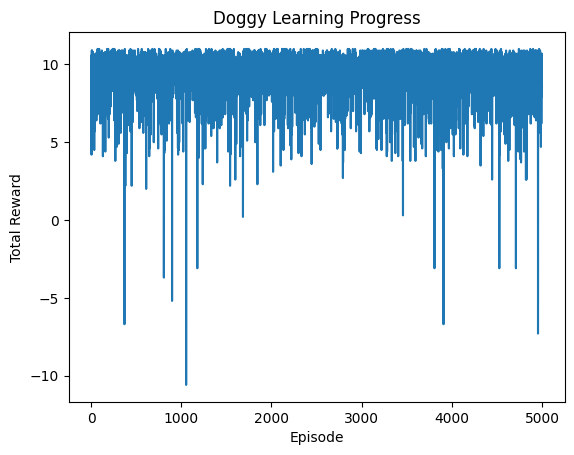

Final Q-table:
[[ 89.9         80.59       100.        ]
 [ 90.1         72.571       79.09      ]
 [ 81.19        65.3539      71.071     ]
 [ 73.171       58.85851     63.8539    ]
 [ 65.9539      53.012659    57.35851   ]
 [ 59.45851     47.7513931   51.51265899]
 [ 53.612659    43.01625303  46.25139309]
 [ 48.3513931   38.75462626  41.51621939]
 [ 43.61625379  34.91905257  37.25438989]
 [ 39.35462841  31.43797507  33.40922998]
 [ 35.51916557  30.88202601  29.65114843]]


In [3]:
# Step 4: Training and Visualization
# Train Doggy
num_episodes = 5000
trained_q_table, episode_rewards = train_Doggy_learning(q_table, num_episodes)

# Print the learned Q-table
print("\nLearned Q-table:")
print(trained_q_table)

# Print optimal policy
print("\nOptimal Policy:")
for state in range(num_states):
    best_action_idx = np.argmax(trained_q_table[state])
    best_action = actions[best_action_idx]
    print(f"State {state} (Distance {state}): {best_action}")
# Visualisation

plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Doggy Learning Progress")
plt.show()

print("Final Q-table:")
print(trained_q_table)


In [4]:
# Improved Q-Learning: Doggy Learns to Kick the Ball
# ========================================
# AIGP Lab 8: Reinforcement Learning - Improved Doggy Example
# Using this version in lab sheet
# ========================================

import numpy as np
import matplotlib.pyplot as plt
import random

# --- Environment setup ---
num_states = 11                      # Distance to the ball: 0–10
actions = ["forward", "backward", "kick"]
num_actions = len(actions)

# --- Parameters ---
alpha = 0.1        # Learning rate
gamma = 0.9        # Discount factor
epsilon = 0.3      # Initial exploration rate
epsilon_min = 0.01 # Minimum exploration
epsilon_decay = 0.995
num_episodes = 500

# Initialize Q-table
q_table = np.zeros((num_states, num_actions))

# --- Reward function ---
def get_reward(state, action):
    if action == "kick":
        if state == 0:
            return 10   # Great job!
        else:
            return -2   # Kicked too early
    elif action == "forward" and state > 0:
        return +0.1     # Encourage moving toward the ball
    elif action == "backward":
        return -0.5     # Discourage moving away
    else:
        return -0.1     # Small penalty for staying put

# --- Transition function ---
def transition(state, action):
    if action == "forward" and state > 0:
        return state - 1  # Move closer
    elif action == "backward" and state < num_states - 1:
        return state + 1  # Move away
    elif action == "kick":
        # State stays the same unless success (handled in training loop)
        return state
    else:
        return state

# --- Epsilon-greedy action selection ---
def choose_action(state, q_table, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # Explore
    else:
        return actions[np.argmax(q_table[state])]  # Exploit best known action

# --- Bellman Q-update ---
def update_q_table(q_table, state, action, reward, next_state):
    a_idx = actions.index(action)
    best_next = np.max(q_table[next_state])
    q_table[state, a_idx] += alpha * (reward + gamma * best_next - q_table[state, a_idx])
    return q_table

# --- Training loop ---
def train_doggy(q_table, num_episodes, epsilon):
    episode_rewards = []

    for episode in range(num_episodes):
        state = random.randint(0, num_states - 1)
        total_reward = 0
        max_steps = 20

        for step in range(max_steps):
            action = choose_action(state, q_table, epsilon)
            reward = get_reward(state, action)
            next_state = transition(state, action)

            # Successful kick ends episode
            if action == "kick" and state == 0:
                q_table = update_q_table(q_table, state, action, reward, next_state)
                total_reward += reward
                break

            # Normal Q-update
            q_table = update_q_table(q_table, state, action, reward, next_state)
            total_reward += reward
            state = next_state

        # Decay exploration rate
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        episode_rewards.append(total_reward)

        # Print progress occasionally
        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}/{num_episodes} | Epsilon: {epsilon:.3f} | Total Reward: {total_reward:.2f}")

    return q_table, episode_rewards


Episode 50/500 | Epsilon: 0.233 | Total Reward: 8.40
Episode 100/500 | Epsilon: 0.182 | Total Reward: 6.80
Episode 150/500 | Epsilon: 0.141 | Total Reward: 10.50
Episode 200/500 | Epsilon: 0.110 | Total Reward: 10.50
Episode 250/500 | Epsilon: 0.086 | Total Reward: 10.20
Episode 300/500 | Epsilon: 0.067 | Total Reward: 10.90
Episode 350/500 | Epsilon: 0.052 | Total Reward: 10.70
Episode 400/500 | Epsilon: 0.040 | Total Reward: 10.50
Episode 450/500 | Epsilon: 0.031 | Total Reward: 10.50
Episode 500/500 | Epsilon: 0.024 | Total Reward: 8.30


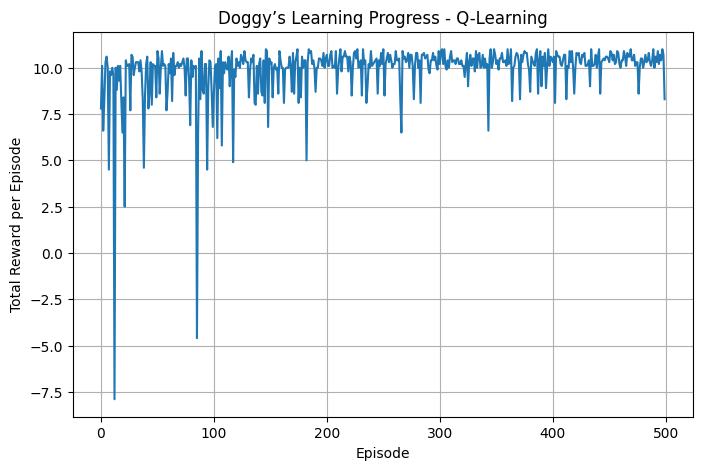


Final Q-Table (states x actions):
Actions: ['forward', 'backward', 'kick']
[[ 5.580e+01  5.249e+01  9.933e+01]
 [ 8.942e+01  4.320e+01  3.199e+01]
 [ 8.050e+01  4.806e+01  4.355e+01]
 [ 7.247e+01  3.653e+01  4.160e+01]
 [ 6.520e+01  2.246e+01  3.701e+01]
 [ 5.863e+01  1.794e+01  1.622e+01]
 [ 5.269e+01  1.491e+01  1.404e+01]
 [ 4.726e+01  1.282e+01  2.660e+00]
 [ 4.213e+01  1.099e+01  7.980e+00]
 [ 3.648e+01  1.360e+00 -3.700e-01]
 [ 2.726e+01 -5.000e-02 -2.000e-01]]

Learned Policy (best action per state):
State 0: kick
State 1: forward
State 2: forward
State 3: forward
State 4: forward
State 5: forward
State 6: forward
State 7: forward
State 8: forward
State 9: forward
State 10: forward


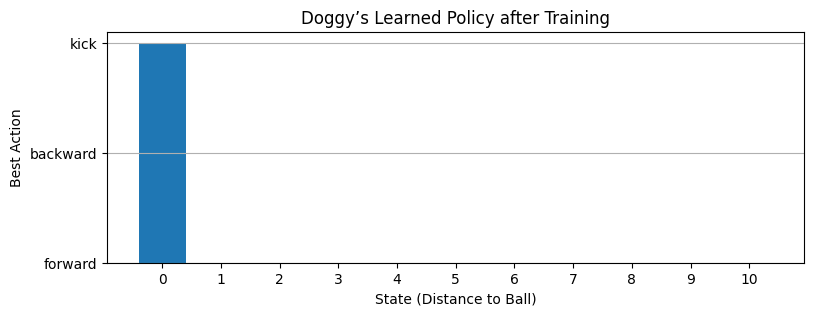

In [5]:
# --- Train the Doggy ---
trained_q_table, rewards = train_doggy(q_table, num_episodes, epsilon)

# --- Visualize learning progress ---
plt.figure(figsize=(8,5))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward per Episode")
plt.title("Doggy’s Learning Progress - Q-Learning")
plt.grid(True)
plt.show()

# --- Display final Q-table ---
print("\nFinal Q-Table (states x actions):")
print("Actions:", actions)
print(np.round(q_table, 2))

# --- Derive Learned Policy ---
policy = [actions[np.argmax(q_table[s])] for s in range(num_states)]

print("\nLearned Policy (best action per state):")
for s in range(num_states):
    print(f"State {s}: {policy[s]}")

# --- Visualize Learned Policy ---
plt.figure(figsize=(9,3))
plt.bar(range(num_states), [actions.index(a) for a in policy], tick_label=[str(s) for s in range(num_states)])
plt.yticks(range(len(actions)), actions)
plt.xlabel("State (Distance to Ball)")
plt.ylabel("Best Action")
plt.title("Doggy’s Learned Policy after Training")
plt.grid(axis='y')
plt.show()

In [ ]:
# Q-Learning Doggy – Animated Visualization
# ========================================
# AIGP Lab 8: Reinforcement Learning
# Doggy Learns to Kick the Ball (with Animation)
# ========================================

import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import time

# --- Environment setup ---
num_states = 11                      # Distance to the ball: 0–10
actions = ["forward", "backward", "kick"]
num_actions = len(actions)

# --- Parameters ---
alpha = 0.1        # Learning rate
gamma = 0.9        # Discount factor
epsilon = 0.3      # Initial exploration rate
epsilon_min = 0.01 # Minimum exploration
epsilon_decay = 0.995
num_episodes = 500

# Initialize Q-table
q_table = np.zeros((num_states, num_actions))

# --- Reward function ---
def get_reward(state, action):
    if action == "kick":
        if state == 0:
            return 10   # Great job!
        else:
            return -2   # Kicked too early
    elif action == "forward" and state > 0:
        return +0.1     # Encourage moving toward the ball
    elif action == "backward":
        return -0.5     # Discourage moving away
    else:
        return -0.1     # Small penalty for staying put

# --- Transition function ---
def transition(state, action):
    if action == "forward" and state > 0:
        return state - 1  # Move closer
    elif action == "backward" and state < num_states - 1:
        return state + 1  # Move away
    elif action == "kick":
        return state      # Stay same (success handled separately)
    else:
        return state

# --- Epsilon-greedy action selection ---
def choose_action(state, q_table, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # Explore
    else:
        return actions[np.argmax(q_table[state])]  # Exploit

# --- Bellman Q-update ---
def update_q_table(q_table, state, action, reward, next_state):
    a_idx = actions.index(action)
    best_next = np.max(q_table[next_state])
    q_table[state, a_idx] += alpha * (reward + gamma * best_next - q_table[state, a_idx])
    return q_table

# --- Training loop ---
def train_doggy(q_table, num_episodes, epsilon):
    episode_rewards = []

    for episode in range(num_episodes):
        state = random.randint(0, num_states - 1)
        total_reward = 0
        max_steps = 20

        for step in range(max_steps):
            action = choose_action(state, q_table, epsilon)
            reward = get_reward(state, action)
            next_state = transition(state, action)

            # Successful kick ends episode
            if action == "kick" and state == 0:
                q_table = update_q_table(q_table, state, action, reward, next_state)
                total_reward += reward
                break

            # Normal Q-update
            q_table = update_q_table(q_table, state, action, reward, next_state)
            total_reward += reward
            state = next_state

        # Decay exploration rate
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}/{num_episodes} | Epsilon: {epsilon:.3f} | Total Reward: {total_reward:.2f}")

    return q_table, episode_rewards

# --- Train the Doggy ---
q_table, rewards = train_doggy(q_table, num_episodes, epsilon)

# --- Visualize learning progress ---
plt.figure(figsize=(8,5))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward per Episode")
plt.title("Doggy’s Learning Progress - Q-Learning")
plt.grid(True)
plt.show()

# --- Derive and print final policy ---
policy = [actions[np.argmax(q_table[s])] for s in range(num_states)]
print("\nLearned Policy (best action per state):")
for s in range(num_states):
    print(f"State {s}: {policy[s]}")

# --- Animation of Doggy moving toward the ball ---
def animate_doggy(policy):
    print("\n Starting Doggy Animation...\n")
    state = 10  # Start far from the ball
    steps = 0
    time.sleep(1)

    while steps < 15:
        clear_output(wait=True)
        action = policy[state]

        # Visualize state
        env = ["_"] * num_states
        env[state] = "🐶"
        env[0] = "⚽"
        print("".join(env))
        print(f"Step {steps}: State = {state}, Action = {action}")

        if action == "kick" and state == 0:
            print("\n Doggy KICKS the ball! Great job!\n")
            break

        # Move to next state
        state = transition(state, action)
        steps += 1
        time.sleep(0.6)

    if state != 0:
        print("\n😅 Doggy didn’t reach the ball this time, but it’s learning!")

# --- Run animation ---
animate_doggy(policy)


⚽__________
Step 10: State = 0, Action = kick

 Doggy KICKS the ball! Great job!

